In [18]:
import pickle
import pandas as pd
import numpy as np
import xidplus
import matplotlib.pyplot as plt
import astropy.convolution as conv
from astropy.io import fits

In [59]:
with open("xid_euclid_wide_v2.2_cirrus_2.5_testing_xid_modelling_PRIMA_2A_coadd_tile79696584_order12_large7.pkl", "rb") as f:
    data = pickle.load(f)

In [ ]:
data["posterior"]

In [60]:
np.percentile(data["posterior"].samples["cirrus_scale"], [2.5, 16,50,84, 97.5])

array([13.7629312 , 14.48854904, 15.18173218, 15.92109192, 16.59074121])

In [6]:
fractal_map = np.load("../../../artemis_lustre/cirrus/cirrus_pipeline/cirrus_2.3_v2.2.npy")

In [7]:
cirrus_map = np.load("../../../artemis_lustre/cirrus/cirrus_pipeline/PRIMA_2A_coadd_v2.npy") * 2.5

In [16]:
fractal_map/cirrus_map

array([[61.27476246, 61.15591446, 61.56026109, ..., 61.89947612,
        61.64306937, 61.61778386],
       [61.11948784, 61.05597697, 61.12337417, ..., 61.70763249,
        61.25406452, 61.21281439],
       [61.4377121 , 61.33294536, 61.33948871, ..., 61.53988132,
        61.42618901, 61.60025411],
       ...,
       [61.79010102, 61.67657606, 61.13791433, ..., 61.50101204,
        61.95318164, 61.96065979],
       [61.97389301, 62.13309812, 61.83437852, ..., 61.67611198,
        61.89131483, 62.1402023 ],
       [61.68726781, 62.09453873, 61.90596921, ..., 61.72167645,
        61.84422977, 61.73992713]], shape=(2215, 2215))

In [27]:
beam = fits.open(f"../../../artemis_lustre/sides/beams/v2/coadd/PRIMA_2A_coadd.fits")[0].data

cirrus_full = conv.convolve_fft(fractal_map, beam, boundary = "wrap", normalize_kernel = True, allow_huge = True)

prior = data["prior"]
cirrus_tile = cirrus_full[prior.sy_pix, prior.sx_pix]

In [21]:
len(prior.sy_pix)

1130

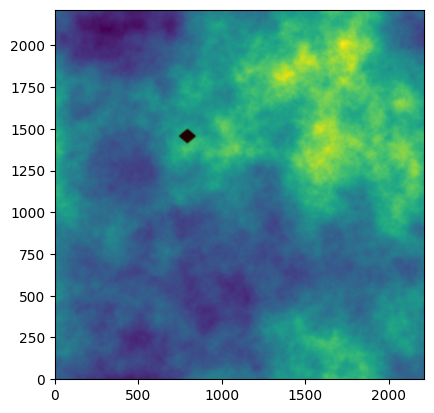

In [65]:
plt.imshow(cirrus_full, origin = "lower")
plt.scatter(prior.sx_pix, prior.sy_pix, c='red', s=0.1, alpha=0.01)

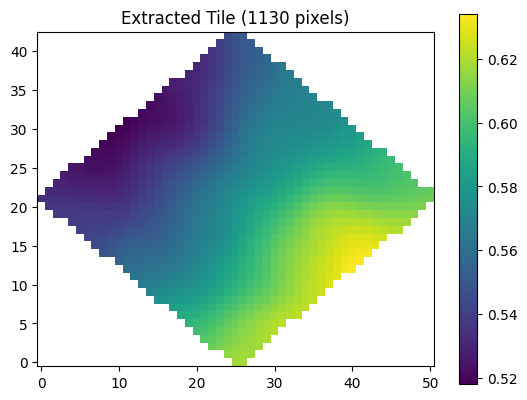

In [33]:
beam = fits.open(f"../../../artemis_lustre/sides/beams/v2/coadd/PRIMA_2A_coadd.fits")[0].data
cirrus_structure = np.load("../../../artemis_lustre/cirrus/cirrus_pipeline/cirrus_2.3_v2.2.npy")
cirrus_structure = conv.convolve_fft(cirrus_structure, beam, boundary = "wrap", normalize_kernel = True, allow_huge = True)
cirrus_structureintile = cirrus_structure[prior.sy_pix, prior.sx_pix]

# 2. Extracted tile (reconstructed 2D)
x_min, x_max = prior.sx_pix.min(), prior.sx_pix.max()
y_min, y_max = prior.sy_pix.min(), prior.sy_pix.max()
cirrus_structureintile2d = np.full((y_max - y_min + 1, x_max - x_min + 1), np.nan)
cirrus_structureintile2d[prior.sy_pix - y_min, prior.sx_pix - x_min] = cirrus_structureintile

plt.imshow(cirrus_structureintile2d, origin='lower', cmap='viridis')
plt.title(f'Extracted Tile ({cirrus_structureintile.size} pixels)')
plt.colorbar()

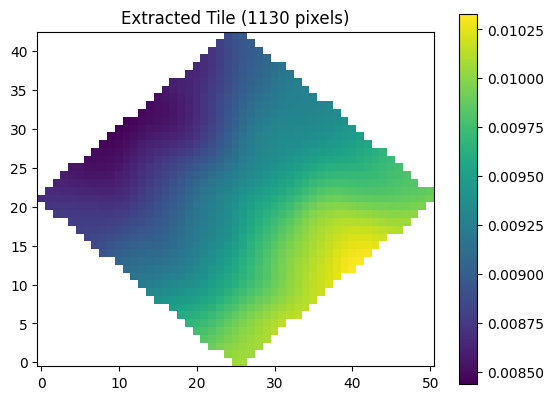

In [32]:
cirrus_inmaptile = cirrus_map[prior.sy_pix, prior.sx_pix]

# 2. Extracted tile (reconstructed 2D)
x_min, x_max = prior.sx_pix.min(), prior.sx_pix.max()
y_min, y_max = prior.sy_pix.min(), prior.sy_pix.max()
cirrus_inmaptile2d = np.full((y_max - y_min + 1, x_max - x_min + 1), np.nan)
cirrus_inmaptile2d[prior.sy_pix - y_min, prior.sx_pix - x_min] = cirrus_inmaptile

plt.imshow(cirrus_inmaptile2d, origin='lower', cmap='viridis')
plt.title(f'Extracted Tile ({cirrus_inmaptile.size} pixels)')
plt.colorbar()

In [40]:
cirrus_inmaptile/cirrus_structureintile

array([0.01628913, 0.01628913, 0.01628913, ..., 0.01628913, 0.01628913,
       0.01628913], shape=(1130,))

In [43]:
0.0065156531807550695*2.5*1000

16.289132951887673

In [ ]:
with open("xid_euclid_wide_v2.2_cirrus_2.5_testing_xid_modelling_larger_tile_PRIMA_2A_coadd_tile19924146_order11_large7.pkl", "rb") as f:
    data = pickle.load(f)
prior = data["prior"]

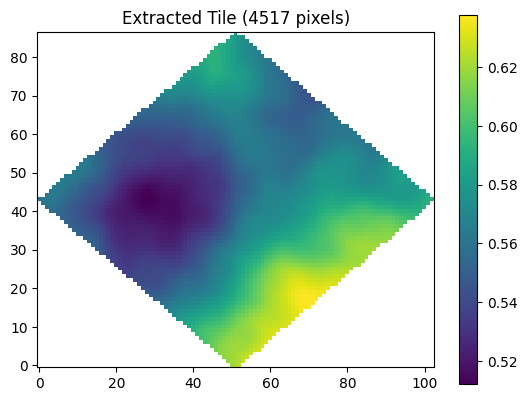

In [55]:
beam = fits.open(f"../../../artemis_lustre/sides/beams/v2/coadd/PRIMA_2A_coadd.fits")[0].data
cirrus_structure = np.load("../../../artemis_lustre/cirrus/cirrus_pipeline/cirrus_2.3_v2.2.npy")
cirrus_structure = conv.convolve_fft(cirrus_structure, beam, boundary = "wrap", normalize_kernel = True, allow_huge = True)
cirrus_structureintile = cirrus_structure[prior.sy_pix, prior.sx_pix]

# 2. Extracted tile (reconstructed 2D)
x_min, x_max = prior.sx_pix.min(), prior.sx_pix.max()
y_min, y_max = prior.sy_pix.min(), prior.sy_pix.max()
cirrus_structureintile2d = np.full((y_max - y_min + 1, x_max - x_min + 1), np.nan)
cirrus_structureintile2d[prior.sy_pix - y_min, prior.sx_pix - x_min] = cirrus_structureintile

plt.imshow(cirrus_structureintile2d, origin='lower', cmap='viridis')
plt.title(f'Extracted Tile ({cirrus_structureintile.size} pixels)')
plt.colorbar()

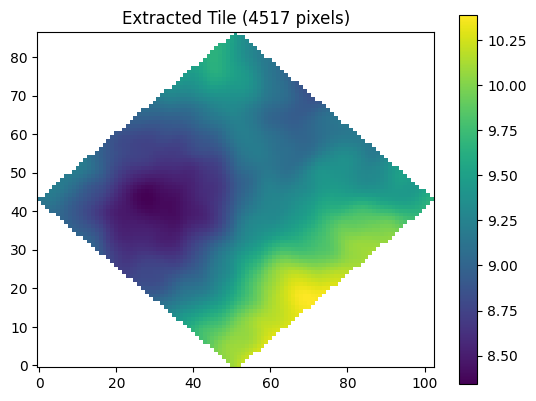

In [56]:
cirrus_inmaptile = cirrus_map[prior.sy_pix, prior.sx_pix] *1e3

# 2. Extracted tile (reconstructed 2D)
x_min, x_max = prior.sx_pix.min(), prior.sx_pix.max()
y_min, y_max = prior.sy_pix.min(), prior.sy_pix.max()
cirrus_inmaptile2d = np.full((y_max - y_min + 1, x_max - x_min + 1), np.nan)
cirrus_inmaptile2d[prior.sy_pix - y_min, prior.sx_pix - x_min] = cirrus_inmaptile

plt.imshow(cirrus_inmaptile2d, origin='lower', cmap='viridis')
plt.title(f'Extracted Tile ({cirrus_inmaptile.size} pixels)')
plt.colorbar()

In [57]:
np.percentile(data["posterior"].samples["cirrus_scale"], [2.5, 16, 50, 84, 97.5])

array([17.88442464, 18.08427795, 18.29183102, 18.49665703, 18.68625202])

In [48]:
cirrus_inmaptile/cirrus_structureintile

array([0.01628913, 0.01628913, 0.01628913, ..., 0.01628913, 0.01628913,
       0.01628913], shape=(4517,))

In [49]:
18.29389477/(0.01628913*1000)

1.1230737780348

In [61]:
with open("xid_euclid_wide_v2.2_cirrus_2.5_testing_xid_modelling_larger_tile_moresamples_PRIMA_2A_coadd_tile19924146_order11_large7.pkl", "rb") as f:
    data = pickle.load(f)
prior = data["prior"]

In [62]:
np.percentile(data["posterior"].samples["cirrus_scale"], [0.2, 2.5, 16, 50, 84, 97.5])

array([17.71403929, 17.88442464, 18.08427795, 18.29183102, 18.49665703,
       18.68625202])

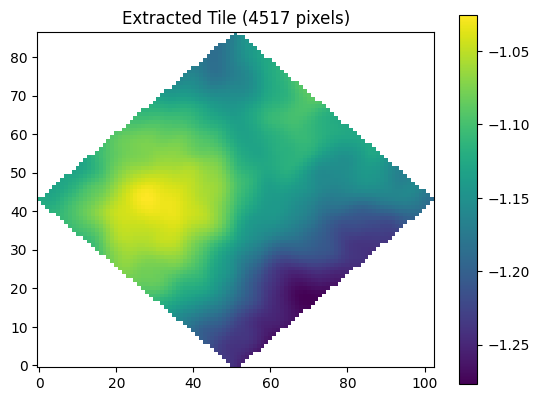

In [58]:
plt.imshow(cirrus_inmaptile2d - cirrus_structureintile2d*18.29183102, origin='lower', cmap='viridis')
plt.title(f'Extracted Tile ({cirrus_inmaptile.size} pixels)')
plt.colorbar()